# EEG Session Classifier — AI vs Non-AI
**USC EEG Creativity Study**

Can we classify whether a participant is coding with or without AI assistance purely from EEG features?

- **Features:** Whole-session band power (Delta, Theta, Alpha, Beta, Gamma) per electrode
- **Labels:** 0 = Unassisted (control), 1 = LLM-Assisted (treatment)
- **Validation:** Leave-One-Subject-Out (LOSO) cross-validation
- **Models:** SVM, Random Forest, Logistic Regression

## 0. Imports

In [12]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
mne.set_log_level('ERROR')

from scipy.signal import welch
from scipy import stats

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print('All imports successful!')

All imports successful!


## 1. Configuration

In [2]:
BASE_PATH = "/Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/clean"
OUTPUT_DIR = "./ml_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BANDS = {
    'Delta':      (1, 4),
    'Theta':      (4, 8),
    'Alpha_Low':  (8, 10),
    'Alpha_High': (10, 12),
    'Alpha':      (8, 12),
    'Beta':       (13, 30),
    'Gamma':      (30, 45),
}

NON_BRAIN = ['A1', 'A2', 'REF', 'GND']
WELCH_N_SEC = 2.0
WELCH_OVERLAP = 0.5

print('Configuration loaded!')

Configuration loaded!


## 2. Load Files

In [3]:
all_files = glob.glob(os.path.join(BASE_PATH, '*.set'))
control_files   = sorted([f for f in all_files if '_control_'   in os.path.basename(f)])
treatment_files = sorted([f for f in all_files if '_treatment_' in os.path.basename(f)])

# Keep only participants with BOTH conditions
ctrl_subjects = set(os.path.basename(f).split('_')[0] for f in control_files)
trt_subjects  = set(os.path.basename(f).split('_')[0] for f in treatment_files)
common = ctrl_subjects & trt_subjects

control_files   = [f for f in control_files   if os.path.basename(f).split('_')[0] in common]
treatment_files = [f for f in treatment_files if os.path.basename(f).split('_')[0] in common]

print(f'Control files:   {len(control_files)}')
print(f'Treatment files: {len(treatment_files)}')
print(f'Participants:    {sorted(common)}')

Control files:   36
Treatment files: 38
Participants:    ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']


## 3. Feature Extraction — Band Power Per Electrode

In [4]:
def extract_features(filepath, bands, welch_n_sec=2.0, overlap=0.5, non_brain=NON_BRAIN):
    """
    Extract band power features from a single EEG file.
    Returns: feature vector (n_bands * n_channels,), channel names
    """
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    
    # Remove non-brain channels
    drop = [ch for ch in non_brain if ch in raw.ch_names]
    if drop:
        raw.drop_channels(drop)
    
    sfreq = raw.info['sfreq']
    n_per_seg = int(welch_n_sec * sfreq)
    n_overlap = int(n_per_seg * overlap)
    
    spectrum = raw.compute_psd(
        method='welch',
        n_fft=n_per_seg,
        n_overlap=n_overlap,
        fmin=1.0,
        fmax=45.0,
        verbose=False
    )
    psd, freqs = spectrum.get_data(return_freqs=True)
    ch_names = spectrum.ch_names
    
    # Compute total power for relative power
    total_power = np.trapz(psd, freqs, axis=1)
    
    features = []
    feature_names = []
    
    for band_name, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        abs_power = np.trapz(psd[:, idx], freqs[idx], axis=1)
        rel_power = abs_power / (total_power + 1e-12)
        
        features.extend(abs_power.tolist())
        features.extend(rel_power.tolist())
        
        for ch in ch_names:
            feature_names.append(f'{band_name}_abs_{ch}')
        for ch in ch_names:
            feature_names.append(f'{band_name}_rel_{ch}')
    
    return np.array(features), feature_names, ch_names

print('Feature extraction function defined!')

Feature extraction function defined!


## 4. Build Dataset

In [5]:
X_list = []
y_list = []  # 0 = unassisted, 1 = llm-assisted
groups_list = []  # subject ID for LOSO
feature_names = None

print('Extracting features from UNASSISTED files...')
for fpath in control_files:
    fname   = os.path.basename(fpath)
    subject = fname.split('_')[0]
    try:
        feats, feat_names, _ = extract_features(fpath, BANDS)
        X_list.append(feats)
        y_list.append(0)
        groups_list.append(subject)
        if feature_names is None:
            feature_names = feat_names
        print(f'  ✓ {fname}')
    except Exception as e:
        print(f'  ✗ {fname}: {e}')

print('\nExtracting features from LLM-ASSISTED files...')
for fpath in treatment_files:
    fname   = os.path.basename(fpath)
    subject = fname.split('_')[0]
    try:
        feats, feat_names, _ = extract_features(fpath, BANDS)
        X_list.append(feats)
        y_list.append(1)
        groups_list.append(subject)
        print(f'  ✓ {fname}')
    except Exception as e:
        print(f'  ✗ {fname}: {e}')

# Stack into arrays — handle different feature lengths
min_len = min(len(x) for x in X_list)
X = np.array([x[:min_len] for x in X_list])
y = np.array(y_list)
groups = np.array(groups_list)
feature_names = feature_names[:min_len]

print(f'\nDataset shape: {X.shape}')
print(f'Labels: {np.bincount(y)} (0=Unassisted, 1=LLM-Assisted)')
print(f'Subjects: {np.unique(groups)}')

Extracting features from UNASSISTED files...
  ✓ P10_control_A3_postcleaning1.set
  ✓ P10_control_B2_postcleaning1.set
  ✓ P11_control_B1_postcleaning1.set
  ✓ P12_control_A3_postcleaning1.set
  ✓ P12_control_B1_postcleaning1.set
  ✓ P13_control_A2_postcleaning1.set
  ✓ P13_control_B3_postcleaning1.set
  ✓ P14_control_A4_postcleaning1.set
  ✓ P14_control_B4_postcleaning1.set
  ✓ P15_control_A2_postcleaning1.set
  ✓ P15_control_B1_postcleaning1.set
  ✓ P16_control_A2_postcleaning1.set
  ✓ P16_control_B3_postcleaning1.set
  ✓ P17_control_A2_postcleaning1.set
  ✓ P17_control_A3_postcleaning1.set
  ✓ P18_control_A3_postcleaning1.set
  ✓ P18_control_B2_postcleaning1.set
  ✓ P20_control_A2_postcleaning1.set
  ✓ P20_control_B1_postcleaning1.set
  ✓ P21_control_B1_postcleaning1.set
  ✓ P22_control_A1_postcleaning1.set
  ✓ P22_control_B4_postcleaning1.set
  ✓ P23_control_A1_postcleaning1.set
  ✓ P23_control_B3_postcleaning1.set
  ✓ P4_control_A1_postcleaning4.set
  ✓ P4_control_A2_postcleaning4

## 5. Average Per Subject Per Condition

In [6]:
# Average features across sessions for same subject+condition
# This gives one feature vector per subject per condition
df_raw = pd.DataFrame(X, columns=feature_names)
df_raw['subject'] = groups
df_raw['label']   = y

df_avg = df_raw.groupby(['subject', 'label']).mean().reset_index()

X_avg = df_avg[feature_names].values
y_avg = df_avg['label'].values
groups_avg = df_avg['subject'].values

print(f'Averaged dataset shape: {X_avg.shape}')
print(f'Labels: {np.bincount(y_avg)} (0=Unassisted, 1=LLM-Assisted)')

Averaged dataset shape: (36, 266)
Labels: [18 18] (0=Unassisted, 1=LLM-Assisted)


## 6. Classification — Leave-One-Subject-Out

In [7]:
logo = LeaveOneGroupOut()

models = {
    'SVM (RBF)':          Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, C=1.0))]),
    'SVM (Linear)':       Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', probability=True, C=1.0))]),
    'Random Forest':      Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
}

print('=== LEAVE-ONE-SUBJECT-OUT CLASSIFICATION RESULTS ===')
print(f'{"Model":<25} {"Accuracy":>10} {"AUC":>10}')
print('-' * 47)

results = {}
for model_name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline, X_avg, y_avg,
        groups=groups_avg,
        cv=logo,
        scoring=['accuracy', 'roc_auc'],
        return_train_score=False
    )
    acc = cv_results['test_accuracy'].mean()
    auc = cv_results['test_roc_auc'].mean()
    results[model_name] = {'accuracy': acc, 'auc': auc, 'cv': cv_results}
    print(f'{model_name:<25} {acc:>10.3f} {auc:>10.3f}')

print('\nChance level: 0.500')

=== LEAVE-ONE-SUBJECT-OUT CLASSIFICATION RESULTS ===
Model                       Accuracy        AUC
-----------------------------------------------
SVM (RBF)                      0.472      0.667
SVM (Linear)                   0.444      0.333
Random Forest                  0.444      0.417
Logistic Regression            0.361      0.222

Chance level: 0.500


## 7. Best Model — Detailed Results

Best model: SVM (RBF)
Accuracy: 0.472
AUC:      0.667

Classification Report:
              precision    recall  f1-score   support

  Unassisted       0.45      0.28      0.34        18
LLM-Assisted       0.48      0.67      0.56        18

    accuracy                           0.47        36
   macro avg       0.47      0.47      0.45        36
weighted avg       0.47      0.47      0.45        36



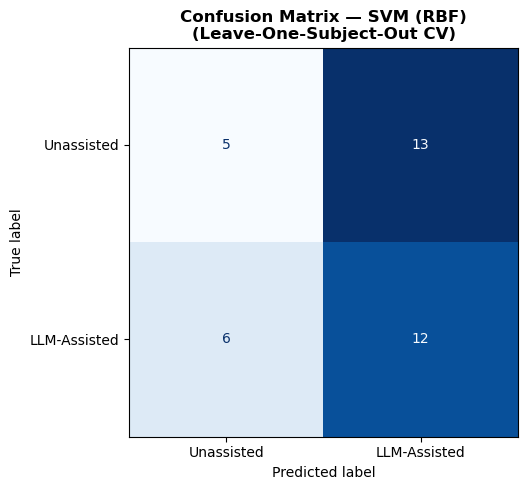

Saved: confusion_matrix.png


In [8]:
# Find best model by AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
print(f'Best model: {best_model_name}')
print(f'Accuracy: {results[best_model_name]["accuracy"]:.3f}')
print(f'AUC:      {results[best_model_name]["auc"]:.3f}')

# Get predictions for confusion matrix
best_pipeline = models[best_model_name]
y_pred_all = np.zeros(len(y_avg))

for train_idx, test_idx in logo.split(X_avg, y_avg, groups_avg):
    best_pipeline.fit(X_avg[train_idx], y_avg[train_idx])
    y_pred_all[test_idx] = best_pipeline.predict(X_avg[test_idx])

print('\nClassification Report:')
print(classification_report(y_avg, y_pred_all, target_names=['Unassisted', 'LLM-Assisted']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_avg, y_pred_all)
disp = ConfusionMatrixDisplay(cm, display_labels=['Unassisted', 'LLM-Assisted'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(Leave-One-Subject-Out CV)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 8. Feature Importance

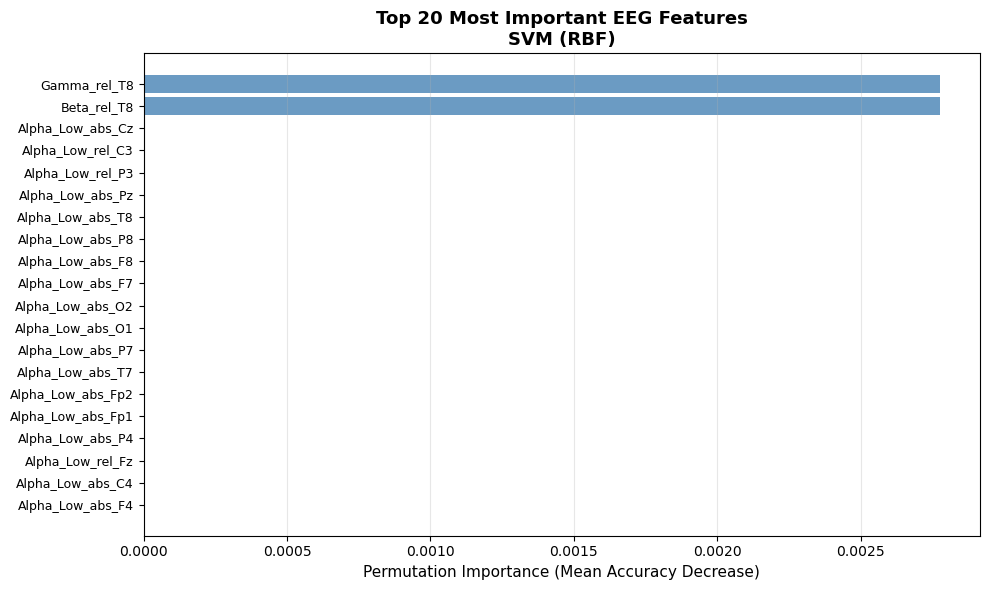

Saved: feature_importance.png


In [9]:
# Fit best model on all data and get feature importances
best_pipeline.fit(X_avg, y_avg)

# Use permutation importance (works for all models)
perm_imp = permutation_importance(
    best_pipeline, X_avg, y_avg,
    n_repeats=30, random_state=42, scoring='accuracy'
)

# Get top 20 most important features
imp_mean = perm_imp.importances_mean
top_idx  = np.argsort(imp_mean)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(20), imp_mean[top_idx][::-1], color='steelblue', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in top_idx[::-1]], fontsize=9)
ax.set_xlabel('Permutation Importance (Mean Accuracy Decrease)', fontsize=11)
ax.set_title(f'Top 20 Most Important EEG Features\n{best_model_name}', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## 9. Model Comparison Plot

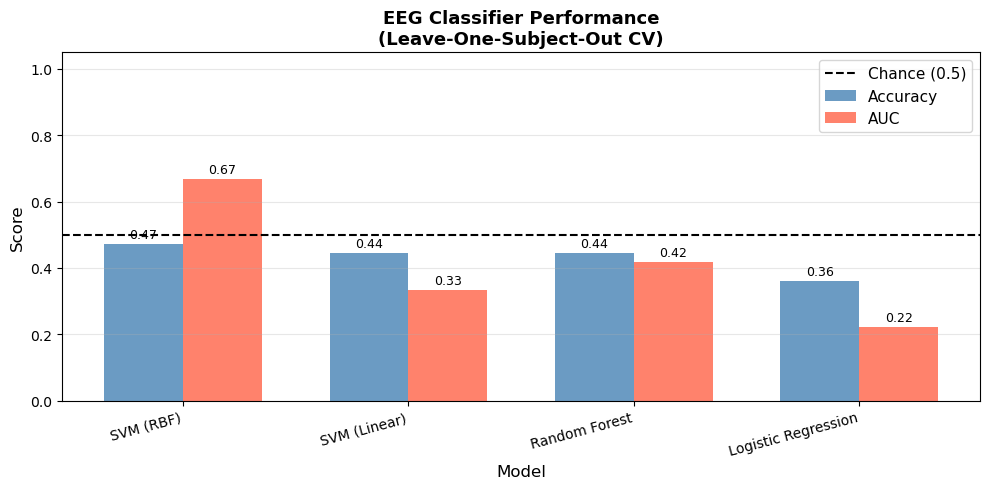

Saved: model_comparison.png


In [10]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
aucs        = [results[m]['auc']      for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, aucs,       width, label='AUC',      color='tomato',    alpha=0.8)

ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='Chance (0.5)')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('EEG Classifier Performance\n(Leave-One-Subject-Out CV)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

## 10. Summary

In [11]:
print('=' * 60)
print('ML CLASSIFIER SUMMARY')
print('=' * 60)
print(f'\nTask: Classify Unassisted vs LLM-Assisted from EEG')
print(f'Features: Band power (abs + rel) per electrode per band')
print(f'Feature dimensions: {X_avg.shape[1]}')
print(f'Samples: {X_avg.shape[0]} ({np.sum(y_avg==0)} Unassisted, {np.sum(y_avg==1)} LLM-Assisted)')
print(f'Validation: Leave-One-Subject-Out CV')
print(f'Chance level: 0.500')

print(f'\n--- Model Results ---')
print(f'{"Model":<25} {"Accuracy":>10} {"AUC":>10}')
print('-' * 47)
for model_name in results:
    acc = results[model_name]['accuracy']
    auc = results[model_name]['auc']
    flag = ' ← BEST' if model_name == best_model_name else ''
    print(f'{model_name:<25} {acc:>10.3f} {auc:>10.3f}{flag}')

print(f'\n--- Top 5 Most Important Features ---')
for i in range(min(5, len(top_idx))):
    print(f'  {i+1}. {feature_names[top_idx[i]]} (importance: {imp_mean[top_idx[i]]:.4f})')

print(f'\n--- Output files ---')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

ML CLASSIFIER SUMMARY

Task: Classify Unassisted vs LLM-Assisted from EEG
Features: Band power (abs + rel) per electrode per band
Feature dimensions: 266
Samples: 36 (18 Unassisted, 18 LLM-Assisted)
Validation: Leave-One-Subject-Out CV
Chance level: 0.500

--- Model Results ---
Model                       Accuracy        AUC
-----------------------------------------------
SVM (RBF)                      0.472      0.667 ← BEST
SVM (Linear)                   0.444      0.333
Random Forest                  0.444      0.417
Logistic Regression            0.361      0.222

--- Top 5 Most Important Features ---
  1. Gamma_rel_T8 (importance: 0.0028)
  2. Beta_rel_T8 (importance: 0.0028)
  3. Alpha_Low_abs_Cz (importance: 0.0000)
  4. Alpha_Low_rel_C3 (importance: 0.0000)
  5. Alpha_Low_rel_P3 (importance: 0.0000)

--- Output files ---
  confusion_matrix.png
  feature_importance.png
  model_comparison.png


In [14]:
# Use only significant channels from spectral analysis
sig_channels = ['Cz', 'P4', 'C4', 'O1', 'Fz']
sig_bands = ['Theta', 'Alpha', 'Beta', 'Gamma']

# Filter feature names - simpler matching
reduced_idx = [i for i, name in enumerate(feature_names) 
               if any(band in name for band in sig_bands)
               and any(name.endswith(ch) for ch in sig_channels)]

X_reduced = X_avg[:, reduced_idx]
reduced_names = [feature_names[i] for i in reduced_idx]

print(f'Reduced features: {X_reduced.shape[1]}')
print('Sample feature names:', reduced_names[:5])

for model_name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline, X_reduced, y_avg,
        groups=groups_avg,
        cv=logo,
        scoring=['accuracy', 'roc_auc'],
    )
    acc = cv_results['test_accuracy'].mean()
    auc = cv_results['test_roc_auc'].mean()
    print(f'{model_name:<25} Acc={acc:.3f}  AUC={auc:.3f}')

Reduced features: 60
Sample feature names: ['Theta_abs_Fz', 'Theta_abs_C4', 'Theta_abs_P4', 'Theta_abs_Cz', 'Theta_abs_O1']
SVM (RBF)                 Acc=0.528  AUC=0.444
SVM (Linear)              Acc=0.361  AUC=0.222
Random Forest             Acc=0.417  AUC=0.444
Logistic Regression       Acc=0.389  AUC=0.111


In [15]:
# Ultra-reduced: just mean power per band across all channels
band_names_simple = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

simple_idx = [i for i, name in enumerate(feature_names)
              if any(name.startswith(band + '_abs') for band in band_names_simple)
              and not any(x in name for x in ['Low', 'High'])]

# Average across channels for each band
X_simple = np.zeros((len(X_avg), len(band_names_simple)))
for b_idx, band in enumerate(band_names_simple):
    band_idx = [i for i, name in enumerate(feature_names) 
                if name.startswith(band + '_abs') and not any(x in name for x in ['Low', 'High'])]
    if band_idx:
        X_simple[:, b_idx] = X_avg[:, band_idx].mean(axis=1)

print(f'Simple features shape: {X_simple.shape}')
print(f'Features: {band_names_simple}')

for model_name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline, X_simple, y_avg,
        groups=groups_avg,
        cv=logo,
        scoring=['accuracy', 'roc_auc'],
    )
    acc = cv_results['test_accuracy'].mean()
    auc = cv_results['test_roc_auc'].mean()
    print(f'{model_name:<25} Acc={acc:.3f}  AUC={auc:.3f}')

Simple features shape: (36, 5)
Features: ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
SVM (RBF)                 Acc=0.611  AUC=0.444
SVM (Linear)              Acc=0.472  AUC=0.167
Random Forest             Acc=0.694  AUC=0.778
Logistic Regression       Acc=0.417  AUC=0.278
